# Clustering of Multilingual Speech Features

**Course:** Machine Learning Basics (Fall 2025)  
**Notebook:** Clustering

This notebook corresponds to **Section 4: Clustering** of the final project and assumes that:
- Audio has already been cleaned and preprocessed in `Data_Cleaning_and_Feature_Extraction.ipynb`.
- Frame-level/statistical features have been extracted and saved to `features.csv`.

We will:
1. Load the extracted features.
2. Apply **unsupervised clustering** algorithms (K-Means and Hierarchical Clustering).
3. Use **Elbow** and **Silhouette** methods to find a good number of clusters (k).
4. Visualize the clusters in 2D using **PCA** and **t-SNE**.

> Note: Although clustering is unsupervised, we will keep the true language labels only for **analysis** (e.g., cluster composition/purity), not for training.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


## 4(a) Load Features & Preprocess

We load the tabular feature representation generated in the previous notebook and perform basic preprocessing:
- Separate **features** from the **language label**.
- Standardize features to zero mean and unit variance (important for distance-based clustering).
- Applying PCA to reduce dimention


In [4]:
# Load extracted features
features_path = "features.csv"
df = pd.read_csv(features_path)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (712, 37)


,mfcc_mean_1,mfcc_std_1,mfcc_mean_2,mfcc_std_2,mfcc_mean_3,mfcc_std_3,mfcc_mean_4,mfcc_std_4,mfcc_mean_5,mfcc_std_5,...,spec_cent_std,spec_bw_mean,spec_bw_std,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std,label
0,-291.26086,144.72418,64.367160,60.317830,7.741365,30.783260,16.433426,26.508999,2.783480,19.631754,...,1555.493066,2255.316452,719.551601,4588.187479,2528.774812,0.115596,0.135309,0.076059,0.069079,German
1,-269.14676,125.91269,67.389500,56.465110,8.639976,28.441526,16.956177,25.995325,3.805025,17.906826,...,1377.099892,2360.271433,588.789207,4706.293612,2303.356182,0.109438,0.116385,0.070596,0.060093,German
2,-263.43262,141.30070,67.129616,61.999280,10.570556,30.036564,19.564170,28.337889,2.044581,19.335743,...,1694.526831,2250.792724,715.386866,4684.390780,2602.442998,0.134017,0.141311,0.083489,0.066240,German
3,-298.88358,142.93672,61.160812,57.830605,4.863456,28.451302,12.690839,24.263693,0.140714,19.187702,...,1526.107939,2327.458581,663.019665,4869.305209,2413.112172,0.125256,0.129976,0.059783,0.057199,German
4,-276.53885,143.90465,64.384930,55.579970,9.792069,27.193563,16.714360,25.317793,2.503405,18.470573,...,1385.330310,2461.853713,534.419750,5036.379381,2271.175386,0.115069,0.119547,0.074286,0.067808,German


In [5]:
# Assume the last column is the language label as created in the feature extraction notebook
feature_cols = df.columns[:-1]
label_col = df.columns[-1]

X = df[feature_cols].values
y_true = df[label_col].values

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Unique languages:", np.unique(y_true))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Number of samples: 712
Number of features: 36
Unique languages: ['German' 'Italian' 'Korean' 'Spanish']


In [6]:
# Apply PCA to reduce dimensionality before clustering
# Determine the number of components that explain a good amount of variance (e.g., 95%)
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 95% of variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components explaining 95% variance: {n_components_95}")
print(f"Explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")

# Apply PCA with the selected number of components
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)

print(f"\nReduced feature space shape: {X_pca.shape}")
print(f"Total explained variance: {pca_final.explained_variance_ratio_.sum():.4f}")

# Use PCA-transformed features for clustering
X_for_clustering = X_pca

Original number of features: 36
Number of components explaining 95% variance: 16
Explained variance ratio (first 10 components): [0.26442736 0.18973396 0.12411922 0.08613255 0.0598385  0.04102545
 0.03766094 0.03092276 0.02504975 0.02012144]

Reduced feature space shape: (712, 16)
Total explained variance: 0.9532


## 4(b) Choosing the Number of Clusters (k)

We first apply **K-Means** for a range of cluster numbers and compute:
- **Inertia (Within-Cluster Sum of Squares)** for the **Elbow method**.
- **Silhouette score** for each k.

We then analyze whether the optimal k is close to the true number of languages (which is 4: German, Italian, Spanish, Korean).


In [7]:
k_values = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_for_clustering)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_for_clustering, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}, silhouette={sil_score:.4f}")


k=2: inertia=19236.26, silhouette=0.3061
k=3: inertia=16059.33, silhouette=0.2323
k=4: inertia=13574.04, silhouette=0.2733
k=5: inertia=11805.59, silhouette=0.3094
k=6: inertia=10541.96, silhouette=0.3218
k=7: inertia=9492.27, silhouette=0.3311
k=8: inertia=8657.70, silhouette=0.3312
k=9: inertia=7944.54, silhouette=0.3494
k=10: inertia=7158.87, silhouette=0.3822


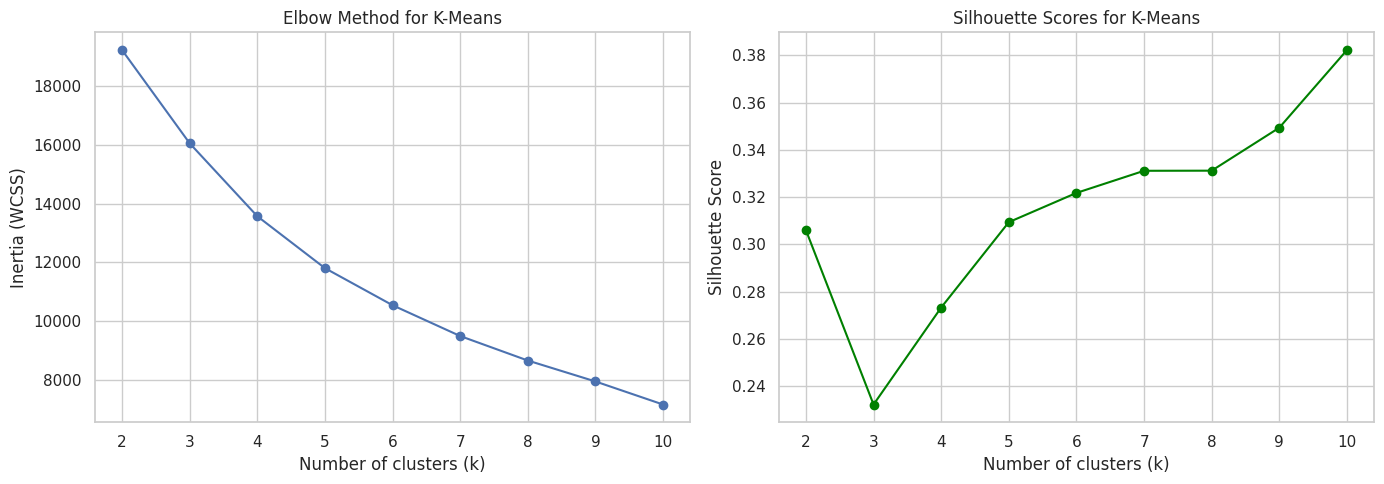

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method (Inertia)
ax[0].plot(k_values, inertias, marker='o')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].set_title('Elbow Method for K-Means')

# Silhouette scores
ax[1].plot(k_values, silhouette_scores, marker='o', color='green')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Scores for K-Means')

plt.tight_layout()
plt.show()


## 4(a) Clustering Algorithms: K-Means and Hierarchical Clustering

Based on the previous plots and the prior knowledge that there are **4 languages**, we now run:
- **K-Means** with `n_clusters = 4`.
- **Agglomerative (Hierarchical) Clustering** with `n_clusters = 4` and Ward linkage.

We report the **Silhouette score** for each clustering result.


In [8]:
n_clusters = 4  # expected number of languages

# K-Means clustering
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_for_clustering)
sil_kmeans = silhouette_score(X_for_clustering, clusters_kmeans)
print(f"K-Means Silhouette Score (k={n_clusters}): {sil_kmeans:.4f}")

# Hierarchical (Agglomerative) clustering
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters_agg = agg.fit_predict(X_for_clustering)
sil_agg = silhouette_score(X_for_clustering, clusters_agg)
print(f"Agglomerative Silhouette Score (k={n_clusters}): {sil_agg:.4f}")

# Export results for Evaluation.ipynb (Silhouette Score & Cluster Purity/composition)
np.savez(
    "clustering_export.npz",
    cluster_labels_kmeans=clusters_kmeans,
    cluster_labels_agg=clusters_agg,
    y_true=y_true,
    silhouette_kmeans=np.array(sil_kmeans),
    silhouette_agg=np.array(sil_agg),
    n_clusters=np.array(n_clusters),
)
print("Clustering results exported to clustering_export.npz")


K-Means Silhouette Score (k=4): 0.2733
Agglomerative Silhouette Score (k=4): 0.2547
Clustering results exported to clustering_export.npz


## 4(c) Visualization in 2D (PCA and t-SNE)

To visualize how well the clusters separate the different languages, we project the high-dimensional feature
space into 2D using:
- **PCA** (linear projection)
- **t-SNE** (non-linear manifold learning; more expensive, but often reveals structure)

We will:
1. Plot the **true languages** in 2D (for reference).
2. Plot the **K-Means clusters**.
3. Plot the **Agglomerative clusters**.


In [8]:
# 2D PCA projection
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance ratio (PCA 2D):", pca_2d.explained_variance_ratio_)


Explained variance ratio (PCA 2D): [0.26442736 0.18973396]


In [9]:
# Helper function for scatter plots
def plot_2d_scatter(X_2d, labels, title, palette='tab10'):
    unique_labels = np.unique(labels)
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=labels,
        palette=palette,
        s=40,
        alpha=0.8
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Label')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.show()


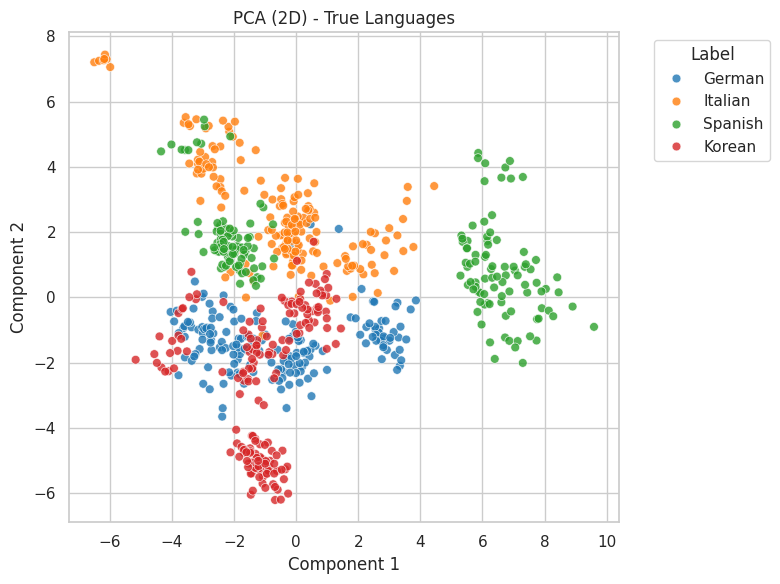

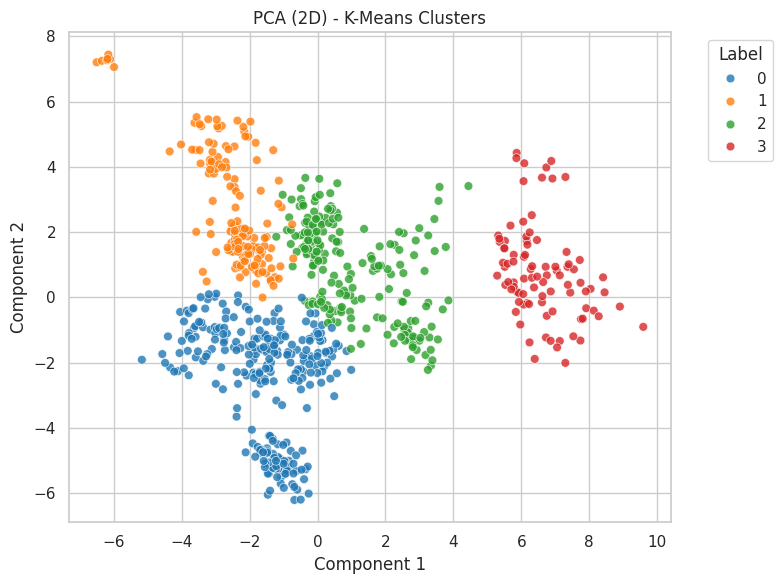

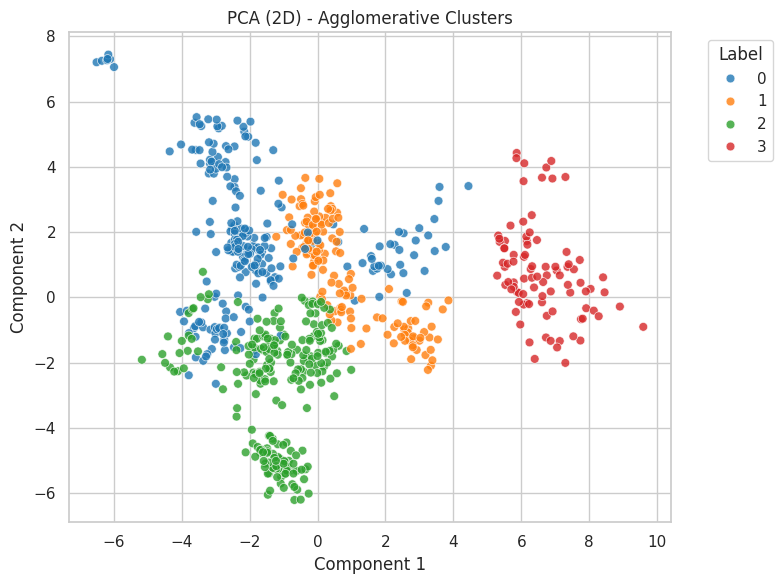

In [10]:
# 1) True languages in PCA space
plot_2d_scatter(X_pca_2d, y_true, "PCA (2D) - True Languages")

# 2) K-Means clusters in PCA space
plot_2d_scatter(X_pca_2d, clusters_kmeans, "PCA (2D) - K-Means Clusters", palette='tab10')

# 3) Agglomerative clusters in PCA space
plot_2d_scatter(X_pca_2d, clusters_agg, "PCA (2D) - Agglomerative Clusters", palette='tab10')


In [11]:
# Helper function for 3D scatter plots
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_scatter(X_3d, labels, title, palette='tab10'):
    """
    Plot 3D scatter plot of data points colored by labels.
    
    Parameters:
    -----------
    X_3d : array-like, shape (n_samples, 3)
        Data points in 3D space
    labels : array-like, shape (n_samples,)
        Labels for coloring points
    title : str
        Title of the plot
    palette : str, default='tab10'
        Color palette name
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap(palette)(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(
            X_3d[mask, 0], 
            X_3d[mask, 1], 
            X_3d[mask, 2],
            c=[colors[i]],
            label=str(label),
            s=40,
            alpha=0.8
        )
    
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Label')
    plt.tight_layout()
    plt.show()


In [12]:
# 3D PCA projection
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print("Explained variance ratio (PCA 3D):", pca_3d.explained_variance_ratio_)
print(f"Total explained variance (3D): {pca_3d.explained_variance_ratio_.sum():.4f}")


Explained variance ratio (PCA 3D): [0.26442736 0.18973396 0.12411922]
Total explained variance (3D): 0.5783


/tmp/ipykernel_106138/1845785216.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(palette)(np.linspace(0, 1, len(unique_labels)))


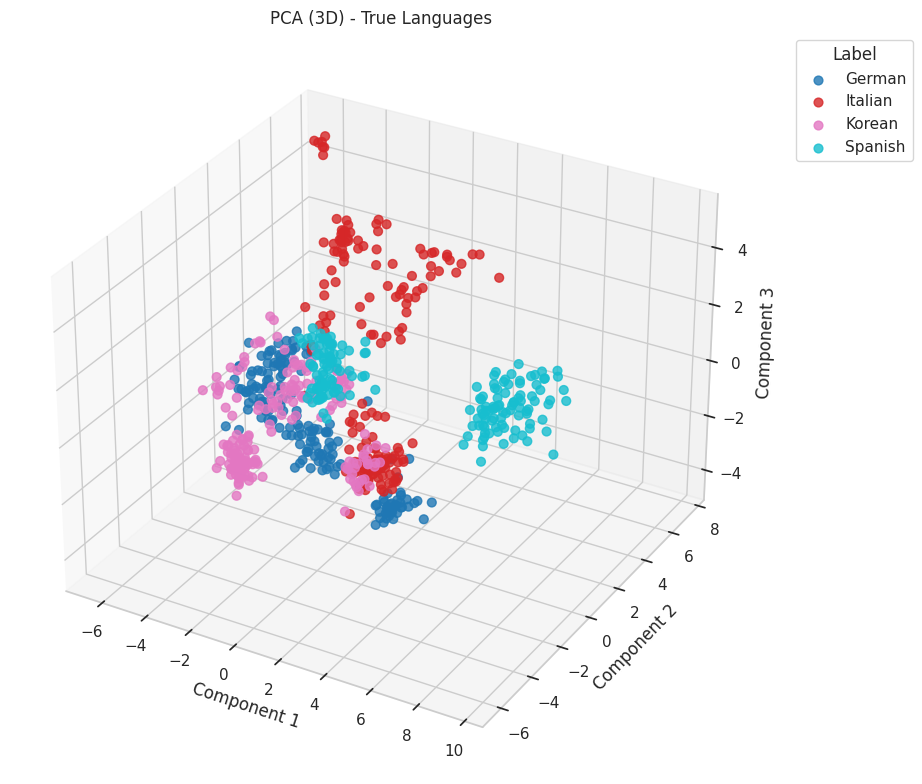

/tmp/ipykernel_106138/1845785216.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(palette)(np.linspace(0, 1, len(unique_labels)))


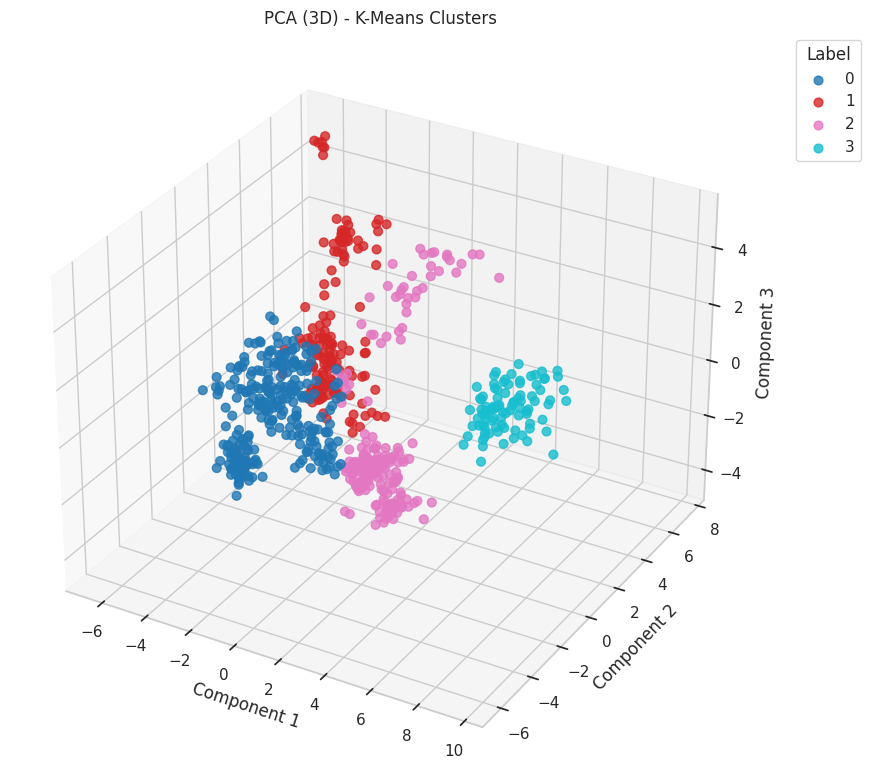

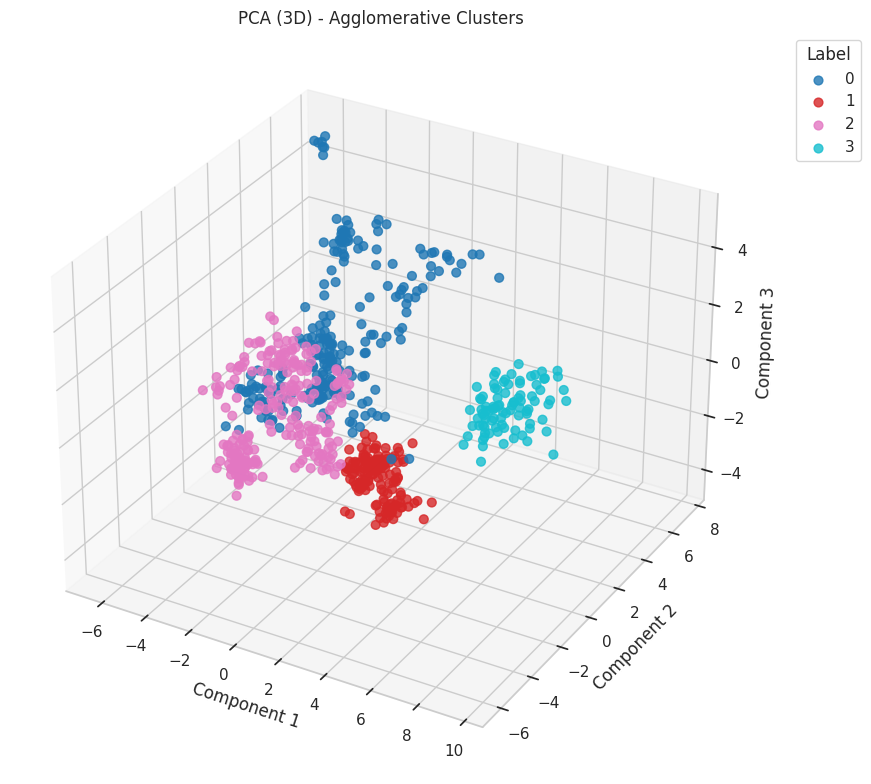

In [13]:
# 1) True languages in PCA 3D space
plot_3d_scatter(X_pca_3d, y_true, "PCA (3D) - True Languages")

# 2) K-Means clusters in PCA 3D space
plot_3d_scatter(X_pca_3d, clusters_kmeans, "PCA (3D) - K-Means Clusters", palette='tab10')

# 3) Agglomerative clusters in PCA 3D space
plot_3d_scatter(X_pca_3d, clusters_agg, "PCA (3D) - Agglomerative Clusters", palette='tab10')


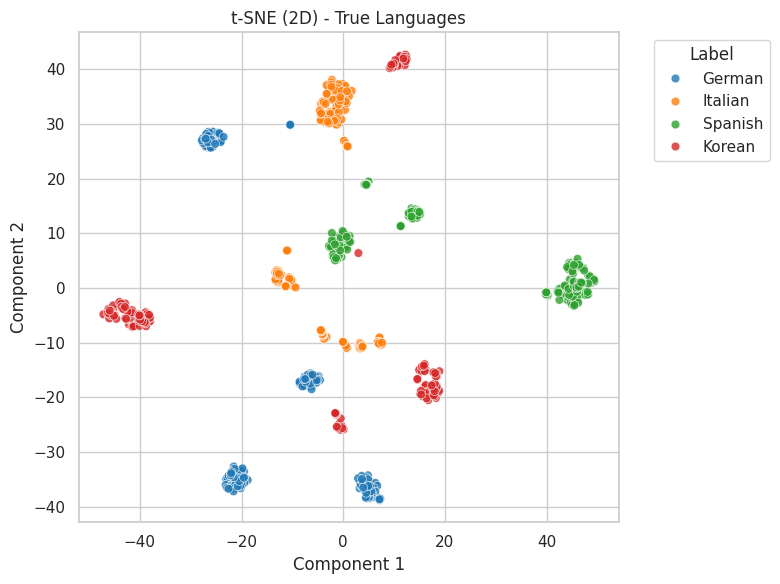

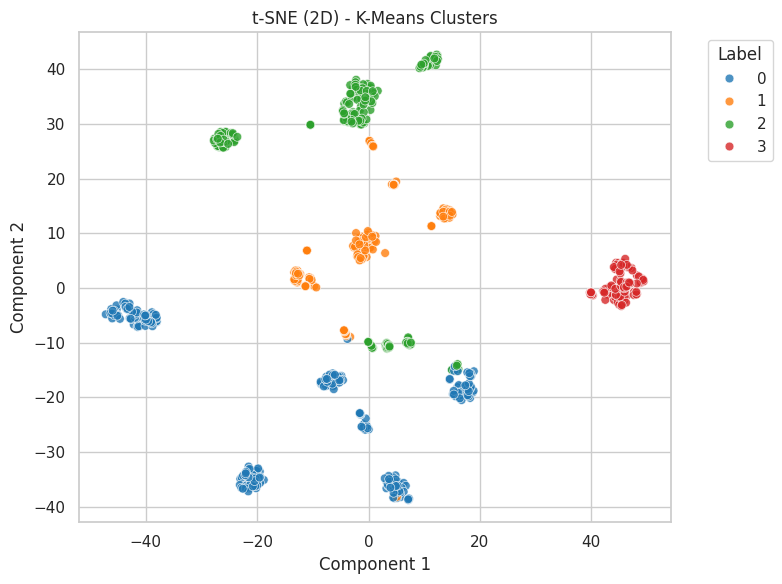

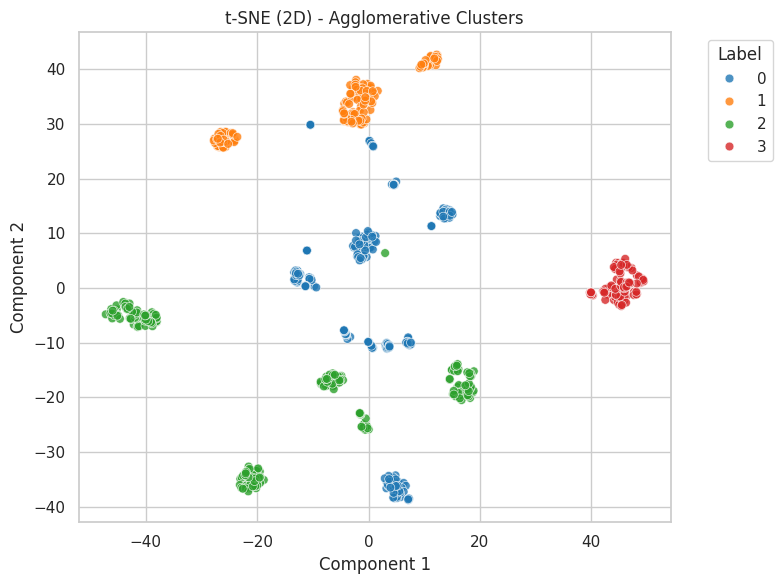

In [14]:
# Optional: t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne_2d = tsne.fit_transform(X_scaled)

# 1) True languages in t-SNE space
plot_2d_scatter(X_tsne_2d, y_true, "t-SNE (2D) - True Languages")

# 2) K-Means clusters in t-SNE space
plot_2d_scatter(X_tsne_2d, clusters_kmeans, "t-SNE (2D) - K-Means Clusters", palette='tab10')

# 3) Agglomerative clusters in t-SNE space
plot_2d_scatter(X_tsne_2d, clusters_agg, "t-SNE (2D) - Agglomerative Clusters", palette='tab10')
